In [17]:
# Si falta alguna libreria en el entorno, descomenta y ejecuta esta celda:
%pip install pandas numpy matplotlib seaborn scikit-learn

# Path nos permite construir rutas de archivos de forma compatible con Windows/Mac/Linux.
from pathlib import Path

# numpy se usa para operaciones numericas y metricas como RMSE.
import numpy as np

# pandas se usa para cargar CSVs y trabajar con tablas.
import pandas as pd

# matplotlib y seaborn se usan para graficos.
import matplotlib.pyplot as plt
import seaborn as sns

# train_test_split divide datos en entrenamiento y test.
from sklearn.model_selection import train_test_split

# Modelos basicos de regresion y clasificacion.
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

# Metricas para evaluar regresion, clasificacion y forecasting.
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
)

# Pipeline empaqueta pasos repetibles; StandardScaler escala variables numericas.
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Estilo visual de los graficos y configuracion de pandas.
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

# Ruta de datos. Funciona tanto si abres el notebook desde su carpeta
# como si lo ejecutas desde la raiz del workspace.
# 1. Tu punto de partida
# Python mirará directamente en la carpeta "ciencia-de_datos"
BASE_DIR = Path.cwd()

# 2. Apuntamos directo a la carpeta de datos
# Como ya estás dentro de "ciencia-de_datos", la carpeta "data" está justo ahí abajo
DATA_DIR = BASE_DIR / "data"

# 3. Construimos las rutas a tus archivos de modelado
ruta_clientes = DATA_DIR / "clientes_modelado.csv"
ruta_ventas = DATA_DIR / "ventas_diarias_modelado.csv"

# 4. Comprobación de seguridad
if ruta_clientes.exists() and ruta_ventas.exists():
    print(f"¡Profesor, todo listo! Conexión establecida con la carpeta de predicciones.")
    print(f"Buscando datos en: {DATA_DIR}\n")
    
    # 5. Carga de datos para tu modelo predictivo
    df_clientes = pd.read_csv(ruta_clientes)
    df_ventas = pd.read_csv(ruta_ventas)
    
    # Verificamos la cantidad de registros que tienes para entrenar tu modelo
    print(f"-> Registros de clientes listos para modelar: {len(df_clientes)}")
    print(f"-> Registros de ventas diarias listos para modelar: {len(df_ventas)}")
else:
    print("❌ ¡Atención, alumno! Algo ha fallado.")
    print(f"El script esperaba encontrar tus archivos en la ruta: {DATA_DIR}")
    print("Verifica que tu Notebook esté guardado en la raíz de 'ciencia-de_datos'.")
 

Note: you may need to restart the kernel to use updated packages.
¡Profesor, todo listo! Conexión establecida con la carpeta de predicciones.
Buscando datos en: c:\Users\Carlos\Documents\Curso_Analisis_Data_bootcamp_Upgrade_Hub\ciencia-de_datos\data

-> Registros de clientes listos para modelar: 900
-> Registros de ventas diarias listos para modelar: 180



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [49]:
# primeras filas de clientes
df_clientes.head()

,edad,ingresos_mensuales,visitas_web_30d,compras_previas,dias_desde_ultima_compra,es_premium,descuento_recibido,gasto_proximo_mes,compra_proximo_mes
0,22,2703.0,5,1,77,0,6.4,197.49,0
1,58,2189.0,5,5,119,0,20.4,244.66,0
2,52,744.0,5,2,83,1,12.2,220.37,0
3,40,3089.0,4,3,133,0,11.9,306.84,0
4,40,1786.0,3,7,154,0,29.2,259.58,1


In [50]:
df_clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   edad                      900 non-null    int64  
 1   ingresos_mensuales        900 non-null    float64
 2   visitas_web_30d           900 non-null    int64  
 3   compras_previas           900 non-null    int64  
 4   dias_desde_ultima_compra  900 non-null    int64  
 5   es_premium                900 non-null    int64  
 6   descuento_recibido        900 non-null    float64
 7   gasto_proximo_mes         900 non-null    float64
 8   compra_proximo_mes        900 non-null    int64  
dtypes: float64(3), int64(6)
memory usage: 63.4 KB


In [51]:
# estadisticas descriptivas de las variables numericas
df_clientes.describe().T

,count,mean,std,min,25%,50%,75%,max
edad,900.0,43.748889,15.172396,18.00,30.000,44.000,57.000,69.00
ingresos_mensuales,900.0,2281.622222,826.787333,700.00,1698.000,2300.000,2824.250,5002.00
visitas_web_30d,900.0,4.917778,2.290357,0.00,3.000,5.000,6.000,13.00
compras_previas,900.0,2.998889,1.799456,0.00,2.000,3.000,4.000,11.00
dias_desde_ultima_compra,900.0,92.292222,51.023999,0.00,48.000,94.000,136.250,179.00
es_premium,900.0,0.272222,0.445351,0.00,0.000,0.000,1.000,1.00
descuento_recibido,900.0,17.366000,9.872485,0.00,8.575,17.650,25.325,35.00
gasto_proximo_mes,900.0,249.957156,72.939158,25.69,197.250,248.675,298.880,494.38
compra_proximo_mes,900.0,0.187778,0.390752,0.00,0.000,0.000,0.000,1.00


## Regresión

In [52]:
# nombre de las columnas
df_clientes.columns 

Index(['edad', 'ingresos_mensuales', 'visitas_web_30d', 'compras_previas',
       'dias_desde_ultima_compra', 'es_premium', 'descuento_recibido',
       'gasto_proximo_mes', 'compra_proximo_mes'],
      dtype='object')

In [53]:
# target de regresion: variable que queremos predecir (variable dependiente o variable objetivo)
target_regresion = "gasto_proximo_mes"

# features de clientes: variables que usaremos para predecir el target (variables independientes o features)
features_clientes = [
    "edad", 
    "ingresos_mensuales",
    "visitas_web_30d",
    "compras_previas",
    "dias_desde_ultima_compra",
    "es_premium",
    "descuento_recibido",
    ]

print("Target de regresion:", target_regresion)
print("Features de clientes:", features_clientes)

Target de regresion: gasto_proximo_mes
Features de clientes: ['edad', 'ingresos_mensuales', 'visitas_web_30d', 'compras_previas', 'dias_desde_ultima_compra', 'es_premium', 'descuento_recibido']


In [54]:
# X contiene la variables de entrada
x = df_clientes[features_clientes]

#y contiene las variables objetivo
y = df_clientes["gasto_proximo_mes"]

# confirmamos que aqui ya no está la variable objetivo
x.head()

,edad,ingresos_mensuales,visitas_web_30d,compras_previas,dias_desde_ultima_compra,es_premium,descuento_recibido
0,22,2703.0,5,1,77,0,6.4
1,58,2189.0,5,5,119,0,20.4
2,52,744.0,5,2,83,1,12.2
3,40,3089.0,4,3,133,0,11.9
4,40,1786.0,3,7,154,0,29.2


In [55]:
y.head()

0    197.49
1    244.66
2    220.37
3    306.84
4    259.58
Name: gasto_proximo_mes, dtype: float64

In [56]:
x_train, x_test, y_train, y_test = train_test_split(
    x, #variables de entrada
    y, #variable objetivo
    test_size=0.2, # 20% de los datos para test, 80% para entrenamiento
    random_state=42 #semilla fija para reproducibilidad
)

#comprobar filas y columnas de cada conjunto
print("Train:", x_train.shape)  
print("Test:", x_test.shape)

Train: (720, 7)
Test: (180, 7)


In [57]:
#creadno el modelo de regresion --> linerRegression
modelo_regresion = LinearRegression()

#entrenamos el modelo con los datos de entrenamiento
modelo_regresion.fit(x_train, y_train)

#predict aplica el modelo entrenado a clientes nuevos (x_test) para predecir su gasto
pred_regresion = modelo_regresion.predict(x_test)

# mostramos las 10 primeras predicciones
pred_regresion[:10]


array([214.42283329, 274.68375581, 245.25167679, 142.87121018,
       286.26842314, 238.89361446, 265.70369905, 206.88694634,
       244.95672655, 186.63260255])

In [58]:
#MAE: error absoluto medio
mae = mean_absolute_error(y_test, pred_regresion)
print("MAE:", mae)

#RMSE: raiz del error cuadratico medio
rmse = np.sqrt(mean_squared_error(y_test, pred_regresion))
print("RMSE:", rmse)

# R2: proporción de varianza explicada por el modelo
r2 = r2_score(y_test, pred_regresion)
print("R2:", r2)

MAE: 30.530999757993555
RMSE: 37.22635080720656
R2: 0.7481579312536297


In [59]:
# creamos una tabla comparativa entre valores reales y predichos

resultados_regresion = pd.DataFrame(
    {
    "real": y_test,
    "predicho": pred_regresion,
    "error_absoluto": abs(y_test - pred_regresion)
    }
).round(2)

# mostramos solo 10 filas
resultados_regresion.head(10)

,real,predicho,error_absoluto
70,188.16,214.42,26.26
827,287.39,274.68,12.71
231,280.57,245.25,35.32
588,80.18,142.87,62.69
39,288.94,286.27,2.67
731,230.54,238.89,8.35
299,294.07,265.70,28.37
110,228.05,206.89,21.16
72,315.81,244.96,70.85
86,142.54,186.63,44.09


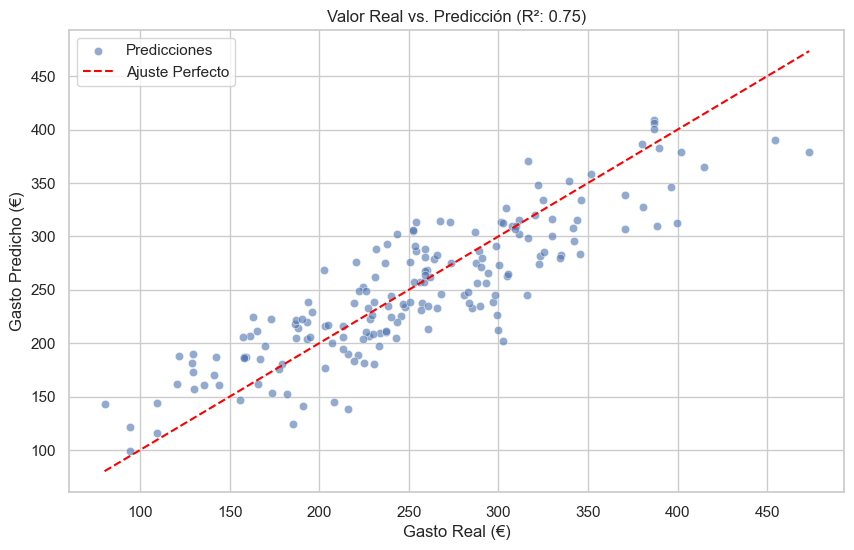

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Dibujamos los puntos (Real vs Predicho)
sns.scatterplot(x=y_test, y=pred_regresion, alpha=0.6, label='Predicciones') # alpha controla la transparencia de los puntos para mejor visualización

# Dibujamos la línea de "Perfección" (donde Real == Predicho)
lims = [min(y_test.min(), pred_regresion.min()), max(y_test.max(), pred_regresion.max())] # Calculamos los límites para que la línea cubra todo el rango de datos
plt.plot(lims, lims, color='red', linestyle='--', label='Ajuste Perfecto')

plt.title(f'Valor Real vs. Predicción (R²: {r2:.2f})')
plt.xlabel('Gasto Real (€)')
plt.ylabel('Gasto Predicho (€)')
plt.legend()
plt.grid(True)
plt.show()

In [61]:
# en un regresion lineal, cada feature tiene un coeficiente que indica su impacto en la prediccion.
# el coeficiente positivo indica que a mayor valor de esa feature, mayor gasto predicho, y viceversa para coeficientes negativos.
# No es causalidad, solo una asociación que el modelo ha aprendido a partir de los datos.

coeficientes = pd.DataFrame(
    {
        "feature": features_clientes,
        "coeficiente": modelo_regresion.coef_
    }
).sort_values(by="coeficiente", ascending=False)

coeficientes

,feature,coeficiente
5,es_premium,72.334410
3,compras_previas,19.811741
2,visitas_web_30d,7.234480
6,descuento_recibido,1.225800
1,ingresos_mensuales,0.041787
0,edad,-0.043616
4,dias_desde_ultima_compra,-0.216591


C:\Users\Carlos\AppData\Local\Temp\ipykernel_14204\3109323101.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coeficiente', y='Feature', data=importances, palette='viridis')


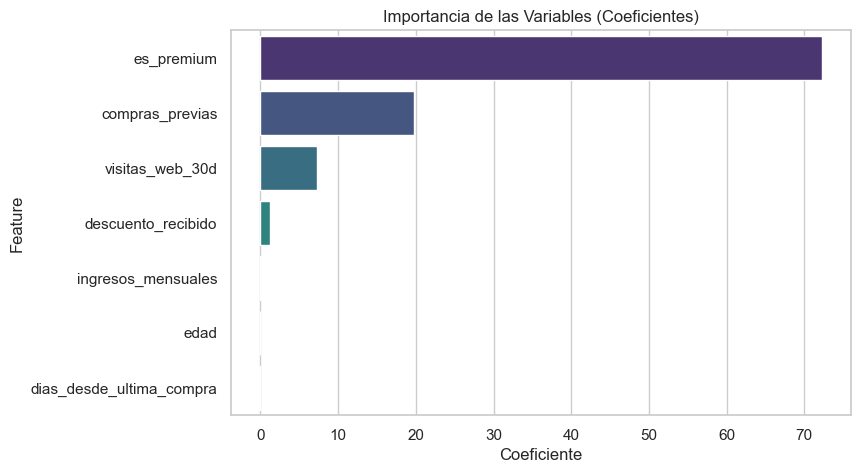

In [62]:
# Extraemos los coeficientes del modelo
importances = pd.DataFrame({
    'Feature': features_clientes,
    'Coeficiente': modelo_regresion.coef_
}).sort_values(by='Coeficiente', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Coeficiente', y='Feature', data=importances, palette='viridis')
plt.title('Importancia de las Variables (Coeficientes)')
plt.show()

Gráfica de Residuos (El "Checkup" del Modelo)
Esta gráfica te dirá si tu modelo lineal es adecuado. Lo ideal es ver puntos dispersos al azar alrededor de la línea de cero. Si ves patrones (como una forma de embudo o una curva), el modelo tiene problemas.

- Si los puntos están dispersos: Tu modelo es robusto.

- Si forman un "embudo": Significa que tu modelo es más impreciso a medida que el gasto aumenta (típico en datos financieros).

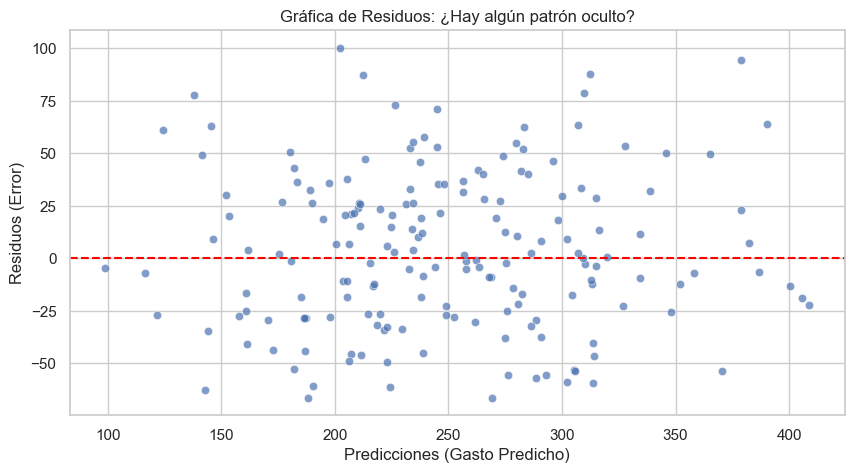

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculamos los residuos
residuos = y_test - pred_regresion # Residuo = Valor Real - Valor Predicho

plt.figure(figsize=(10, 5))

# Graficamos los residuos vs las predicciones
sns.scatterplot(x=pred_regresion, y=residuos, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--') # Línea de error cero

plt.title('Gráfica de Residuos: ¿Hay algún patrón oculto?')
plt.xlabel('Predicciones (Gasto Predicho)')
plt.ylabel('Residuos (Error)')
plt.grid(True)
plt.show()

Distribución del Error
¿Tus errores siguen una campana de Gauss? Es importante saber si sueles equivocarte por mucho o por poco.

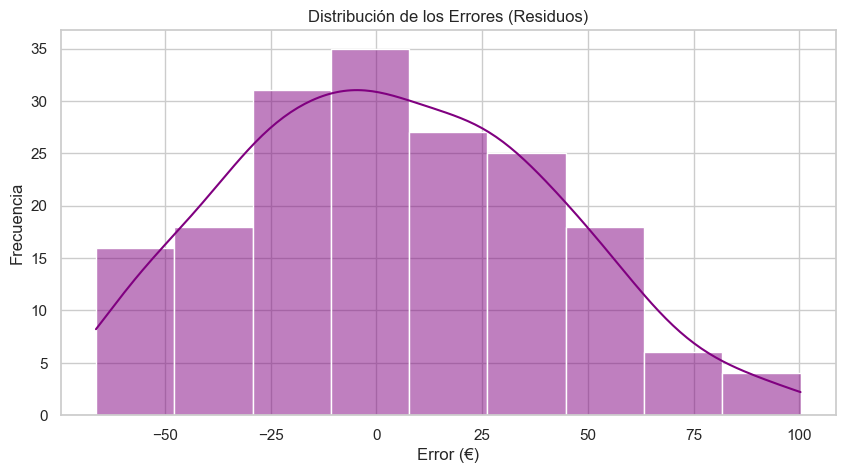

In [64]:
plt.figure(figsize=(10, 5))
sns.histplot(residuos, kde=True, color='purple')
plt.title('Distribución de los Errores (Residuos)')
plt.xlabel('Error (€)')
plt.ylabel('Frecuencia')
plt.show()

EL coeficiente dice causalidad?

NO!  En este modelo lineal dice asociación dentro del modelo, manteniendo el resto ed variables constantes.

Regresion con menos variables.

Utilizad:
 -"visitas_web_30d"
 -"compras_previas"
 -"es_premium"

Pierde mucho rendimiento el modelo si usamos menos informacion?

In [32]:
features_reto_regresion = [
    "visitas_web_30d",
    "compras_previas",
    "es_premium",
]

# X_reto contiene solo esas tres variables.
X_reto = df_clientes[features_reto_regresion]

# La y es la misma que antes: queremos predecir el gasto del proximo mes.
y_reto = df_clientes["gasto_proximo_mes"]

# Repetimos la misma separacion train/test para comparar de forma justa.
X_train_reto, X_test_reto, y_train_reto, y_test_reto = train_test_split(
    X_reto,
    y_reto,
    test_size=0.2,
    random_state=42,
)

# Entrenamos otro modelo lineal, pero ahora con menos columnas.
modelo_reto_regresion = LinearRegression()
modelo_reto_regresion.fit(X_train_reto, y_train_reto)

# Predecimos sobre test y calculamos MAE.
pred_reto_regresion = modelo_reto_regresion.predict(X_test_reto)
mae_reto_regresion = mean_absolute_error(y_test_reto, pred_reto_regresion)

print(f"MAE modelo completo: {mae:.2f}")
print(f"MAE modelo con 3 variables: {mae_reto_regresion:.2f}")

MAE modelo completo: 30.53
MAE modelo con 3 variables: 43.20


El concepto de "Underfitting" vs "Overfitting"
Como estás empezando, este es el concepto teórico más relevante que debes "visualizar" en tu mente. Define la calidad de tu trabajo futuro:

- Underfitting (Subajuste): El modelo es demasiado simple. Es como intentar explicar el mercado de seguros solo con la edad del cliente. No aprende lo suficiente (ni en entrenamiento ni en test).

- Overfitting (Sobreajuste): El modelo es tan complejo que memoriza los datos de entrenamiento (incluyendo el ruido y errores puntuales). En x_train tiene un error de 0, pero cuando le pasas x_test, falla totalmente. Es el enemigo número uno.

## CLasificación

In [65]:
df_clientes.head()

,edad,ingresos_mensuales,visitas_web_30d,compras_previas,dias_desde_ultima_compra,es_premium,descuento_recibido,gasto_proximo_mes,compra_proximo_mes
0,22,2703.0,5,1,77,0,6.4,197.49,0
1,58,2189.0,5,5,119,0,20.4,244.66,0
2,52,744.0,5,2,83,1,12.2,220.37,0
3,40,3089.0,4,3,133,0,11.9,306.84,0
4,40,1786.0,3,7,154,0,29.2,259.58,1


In [66]:
x = df_clientes[features_clientes]
y = df_clientes["compra_proximo_mes"]

y.value_counts(normalize=True).rename({0: "No compra", 1: "Compra"})

compra_proximo_mes
No compra    0.812222
Compra       0.187778
Name: proportion, dtype: float64

In [67]:
x.head()

,edad,ingresos_mensuales,visitas_web_30d,compras_previas,dias_desde_ultima_compra,es_premium,descuento_recibido
0,22,2703.0,5,1,77,0,6.4
1,58,2189.0,5,5,119,0,20.4
2,52,744.0,5,2,83,1,12.2
3,40,3089.0,4,3,133,0,11.9
4,40,1786.0,3,7,154,0,29.2


In [68]:
y.head()

0    0
1    0
2    0
3    0
4    1
Name: compra_proximo_mes, dtype: int64

In [69]:
x_train, x_test, y_train, y_test = train_test_split(
    x, 
    y, 
    test_size=0.2, #20% de los datos para test, 80% para entrenamiento
    random_state=42, # semilla fija para reproducibilidad
    stratify=y # estratificamos para mantener la misma proporción de clases en train y test
)

y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)

(compra_proximo_mes
 0    0.8125
 1    0.1875
 Name: proportion, dtype: float64,
 compra_proximo_mes
 0    0.811111
 1    0.188889
 Name: proportion, dtype: float64)

In [ ]:
# LogisticRegression es un modelo clasico de clasificacion
# Aunque ponga regresion no es para regresion, es para clasificacion binaria.
modelo_clasificacion = LogisticRegression(max_iter=1000)


modelo_clasificacion.fit(x_train, y_train) # entrenamos el modelo con los datos de entrenamiento

prod_clasificacion = modelo_clasificacion.predict(x_test) # predict devuelve 0 o 1, la clase predicha para cada cliente de test.

prod_clasificacion[:10] # mostramos las 10 primeras predicciones de compra (1) o no compra (0)

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0])

In [71]:
# Procentaje total de aciertos del modelo,
# es decir, la proporción de clientes que el modelo clasificó correctamente como compradores o no compradores.
accuracy = accuracy_score(y_test, prod_clasificacion)
print("Accuracy:", accuracy)
# Precision: de todos los clientes que el modelo predijo como compradores (compra_proximo_mes=1),
# qué proporción realmente compró.
precision = precision_score(y_test, prod_clasificacion)
print("Precision:", precision)
# Recall: de todos los clientes que realmente compraron, qué proporción el modelo identificó correctamente como compradores.
recall = recall_score(y_test, prod_clasificacion)
print("Recall:", recall)
# F1 Score: la media armónica entre precision y recall, que penaliza modelos que tengan un desequilibrio entre ambos.
f1 = f1_score(y_test, prod_clasificacion)
print("F1 Score:", f1)  


# Alta precision y alto recall: el modelo maneja perfectamente esa clase
# Alta precision y bajo recall: el modelo no detecta la clase muy bien, pero cuando lo hace es altamente confiable.
# Baja precisión y alto recall: La clase detecta bien la clase pero también incluye muestras de otras clases.
# Baja precisión y bajo recall: El modelo no logra clasificar la clase correctamente.

Accuracy: 0.8111111111111111
Precision: 0.5
Recall: 0.17647058823529413
F1 Score: 0.2608695652173913


## La Matriz de Confusión
Es la tabla más importante, dice exactamente dónde se está confundiendo el modelo.

¿Qué buscar aquí?

- Verdaderos Positivos (VP): Predijiste "Compra" y compró.

- Verdaderos Negativos (VN): Predijiste "No compra" y no compró.

- Falsos Positivos (FP) - Error Tipo I: Predijiste "Compra" pero NO compró (gastas dinero en marketing innecesario).

- Falsos Negativos (FN) - Error Tipo II: Predijiste "No compra" pero SÍ compró (¡pierdes una venta!).

<Figure size 800x600 with 0 Axes>

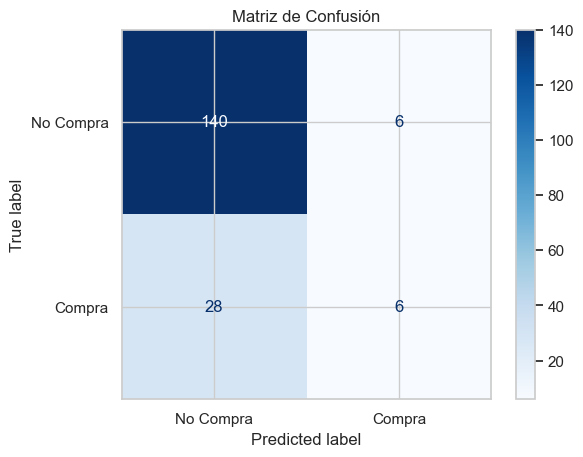

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Creamos la matriz de confusión muestra el número de verdaderos positivos, falsos positivos, verdaderos negativos y falsos negativos.

cm = confusion_matrix(y_test, prod_clasificacion) 
# La visualizamos de forma elegante
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Compra', 'Compra'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión')
plt.show()

## Curva ROC y AUC (El equilibrio potencia/error)
El Accuracy puede engañar (si el 90% no compra, un modelo que siempre diga "No compra" tendrá un 90% de accuracy pero será inútil). La Curva ROC muestra cómo se comporta el modelo variando su "umbral" de decisión

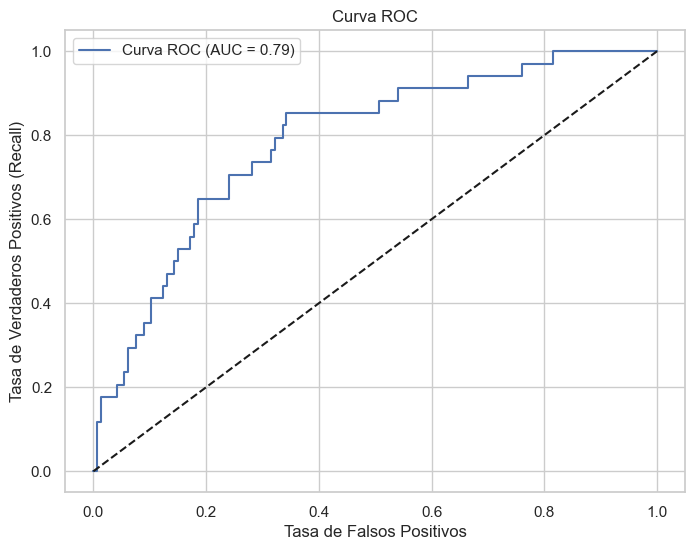

In [73]:
from sklearn.metrics import roc_curve, roc_auc_score

# Necesitamos las probabilidades, no solo la clase final (0 o 1)
probs = modelo_clasificacion.predict_proba(x_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, probs)
auc = roc_auc_score(y_test, probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Curva ROC (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--') # Línea de azar
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.title('Curva ROC')
plt.legend()
plt.show()

Reporte de Clasificación (Tabla de resumen)
En lugar de imprimir una a una las métricas, usa el classification_report. Te dará las métricas para cada clase (los que compran y los que no).

In [74]:
from sklearn.metrics import classification_report
print(classification_report(y_test, prod_clasificacion, target_names=['No Compra', 'Compra']))

              precision    recall  f1-score   support

   No Compra       0.83      0.96      0.89       146
      Compra       0.50      0.18      0.26        34

    accuracy                           0.81       180
   macro avg       0.67      0.57      0.58       180
weighted avg       0.77      0.81      0.77       180



Entrenar otro clasificador.

Antes usamos --> LogisticRegression
Ahora ---------> RandomForestClassifier

Preguntas?

- Mejora el accuracy?
- Mejora el recall de la clase compra?
- que modelo elegir si el objetivo es detectas más posibles compradores?

In [42]:
# Usamos la misma X e y que en la clasificacion anterior.
X = df_clientes[features_clientes]
y = df_clientes["compra_proximo_mes"]

# Repetimos la misma particion para comparar modelos de forma justa.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# RandomForestClassifier combina muchos arboles de decision.
# n_estimators indica cuantos arboles se entrenan.
# min_samples_leaf evita hojas demasiado pequeñas y reduce sobreajuste.
modelo_rf_clasificacion = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    min_samples_leaf=3,
)

# Entrenamos el bosque aleatorio.
modelo_rf_clasificacion.fit(X_train, y_train)

# Predecimos clases para el conjunto de test.
pred_rf_clasificacion = modelo_rf_clasificacion.predict(X_test)

# Comparamos metricas principales.
print("RandomForestClassifier")
print(f"Accuracy:  {accuracy_score(y_test, pred_rf_clasificacion):.3f}")
print(f"Precision: {precision_score(y_test, pred_rf_clasificacion):.3f}")
print(f"Recall:    {recall_score(y_test, pred_rf_clasificacion):.3f}")
print(f"F1:        {f1_score(y_test, pred_rf_clasificacion):.3f}")

RandomForestClassifier
Accuracy:  0.817
Precision: 0.556
Recall:    0.147
F1:        0.233


## Forecasting - Predecir el futuro.

In [75]:
df_ventas = pd.read_csv(DATA_DIR / "ventas_diarias_modelado.csv", parse_dates=["fecha"])

df_ventas.tail()

,fecha,ventas,dia,dia_semana,es_fin_de_semana,promo
175,2025-06-25,201.0,175,2,0,0
176,2025-06-26,195.0,176,3,0,0
177,2025-06-27,201.0,177,4,0,0
178,2025-06-28,168.0,178,5,1,0
179,2025-06-29,161.0,179,6,1,0


In [76]:
df_ventas.head()

,fecha,ventas,dia,dia_semana,es_fin_de_semana,promo
0,2025-01-01,125.0,0,2,0,0
1,2025-01-02,190.0,1,3,0,1
2,2025-01-03,131.0,2,4,0,0
3,2025-01-04,93.0,3,5,1,0
4,2025-01-05,92.0,4,6,1,0


In [77]:
train = df_ventas.iloc[:-14].copy()  # Usamos todo excepto los últimos 14 días para entrenar
test = df_ventas.iloc[-14:].copy()   # Usamos los últimos 14 días para test


# Mostramos los rangos de fecha para reforzar la idea pasado -> futuro.
print("Train:", train["fecha"].min().date(), "a", train["fecha"].max().date())
print("Test: ", test["fecha"].min().date(), "a", test["fecha"].max().date())

Train: 2025-01-01 a 2025-06-15
Test:  2025-06-16 a 2025-06-29


In [78]:
# baseline: regla sencilla antes de entrenar un modelo complejo, siempre es bueno tener una referencia simple para comparar.
# shift(7) trae la venta de hace 7 dias para cada fecha
test["pred_baseline_7d"] = df_ventas["ventas"].shift(7).loc[test.index]

mae_baseline = mean_absolute_error(test["ventas"], test["pred_baseline_7d"])
print("MAE baseline 7 dias:", mae_baseline)

MAE baseline 7 dias: 22.357142857142858


In [79]:
features_forecasting = ["dia", "dia_semana", "es_fin_de_semana","promo"]

target_forecasting = "ventas"

modelo_forecasting = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    min_samples_leaf=3,
)

modelo_forecasting.fit(train[features_forecasting], train[target_forecasting])

pred_forecasting = modelo_forecasting.predict(test[features_forecasting])

mae_forecasting = mean_absolute_error(test["ventas"], pred_forecasting)
print("MAE modelo forecasting:", mae_forecasting)

MAE modelo forecasting: 8.659420276152415


La Gráfica de la "Verdad" en el Tiempo
En forecasting, no usamos scatter plots (puntos sueltos) como en la regresión normal. Usamos gráficos de líneas. Queremos ver si nuestro modelo captura la "forma" de la demanda (subidas en fin de semana, picos por promociones).

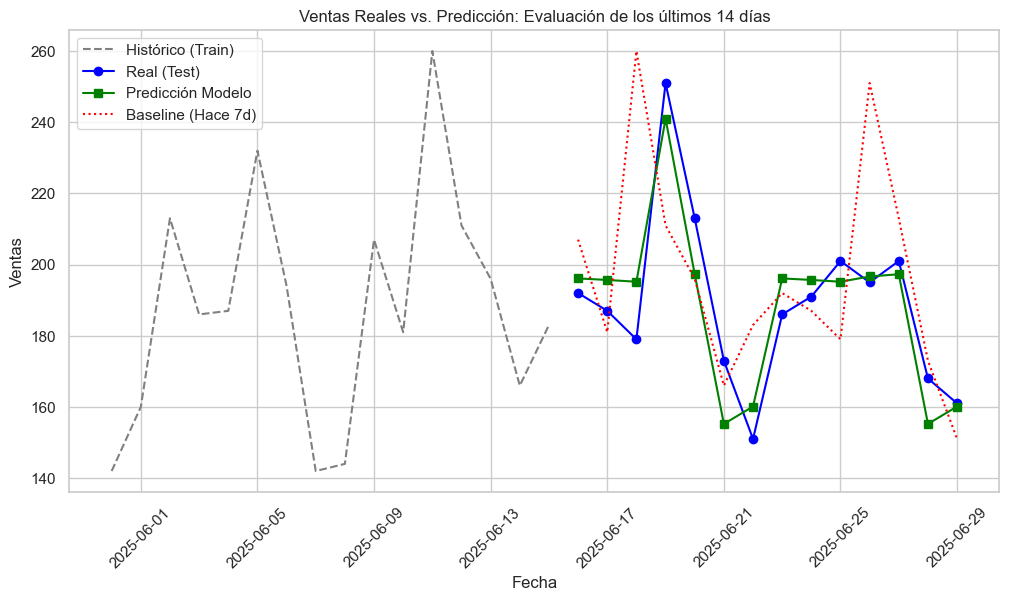

In [80]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Dibujamos los datos reales de los últimos 30 días para contexto
plt.plot(train["fecha"].tail(16), train["ventas"].tail(16), label='Histórico (Train)', color='gray', linestyle='--')
plt.plot(test["fecha"], test["ventas"], label='Real (Test)', color='blue', marker='o')

# Dibujamos las predicciones
plt.plot(test["fecha"], pred_forecasting, label='Predicción Modelo', color='green', marker='s')
plt.plot(test["fecha"], test["pred_baseline_7d"], label='Baseline (Hace 7d)', color='red', linestyle=':')

plt.title('Ventas Reales vs. Predicción: Evaluación de los últimos 14 días')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

Conceptos de Oro: Lo que separa a un Junior de un Senior
A. El concepto de "Lags" (Retardos)
Tu modelo actual usa el dia_semana o si hay promo. Pero en el mundo real, lo que más influye en lo que venderás hoy es lo que vendiste ayer o hace una semana.

Aprendizaje: Debes aprender a crear columnas nuevas como venta_ayer o media_movil_7d. Esto se llama Feature Engineering para series temporales.

B. Estacionalidad y Tendencia
Tendencia: ¿Las ventas suben mes a mes?

Estacionalidad: ¿Todos los lunes vendemos poco y los sábados mucho?
El modelo debe ser capaz de identificar estos ciclos.

C. Ventana Desplazada (Rolling Windows)
Un buen profesional no solo mira un punto atrás, mira una "ventana". Por ejemplo: "El promedio de ventas de los últimos 3 días".

El Forecasting es, probablemente, la rama del Machine Learning que más valor directo aporta a la toma de decisiones estratégicas. En sectores como el de seguros o la industria, no solo importa el "qué", sino el "cuándo".

Para que tus investigaciones sean productivas, te dejo los 3 conceptos maestros que diferencian a un analista que "hace gráficas" de uno que "predice el futuro" con rigor:

1. La Estacionariedad (Stationarity)
Un error común es intentar predecir una serie que tiene una tendencia muy marcada (por ejemplo, ventas que siempre suben) sin tratarla antes.

Concepto: Una serie es estacionaria si su media y su varianza no cambian en el tiempo.

Importancia: La mayoría de los modelos estadísticos clásicos (como ARIMA) asumen que la serie es estacionaria. Si tus datos suben como una rampa, tendrás que aplicar "Diferenciación" (restar el valor de hoy menos el de ayer) para que el modelo pueda trabajar bien.

2. La Ingeniería de Características Temporales (Lags)
En el código que viste en clase, usabas el "día de la semana". Pero en Forecasting, la variable más potente suele ser el pasado inmediato.

Lag 1: La venta de ayer.

Lag 7: La venta de hace justo una semana.

Ventanas móviles (Rolling Windows): El promedio de ventas de los últimos 3 o 7 días. Estas variables ayudan al modelo a entender la "inercia" del negocio.

3. La Validación Cruzada Temporal (Time Series Cross-Validation)
En la clase usaste un "corte" simple (los últimos 14 días). Pero un profesional usa lo que llamamos "Ventanas Desplazadas".

No basta con probar una vez. Entrenas hasta enero y pruebas febrero. Luego entrenas hasta febrero y pruebas marzo.

Esto asegura que tu modelo no tuvo "suerte" en esos 14 días específicos, sino que es robusto en cualquier momento del año.

¿Por dónde seguir investigando?
Si quieres profundizar, te sugiero buscar estos términos en este orden:

Modelos Clásicos: Entender qué es un modelo ARIMA o Exponential Smoothing.

Modelos de Meta (Facebook): Investiga sobre Prophet. Es una librería muy famosa que automatiza gran parte del trabajo sucio de las series temporales.

Librerías de Python: Echa un vistazo a skforecast. Es una librería española excelente que permite usar modelos como el Random Forest que viste hoy para hacer predicciones a futuro de forma muy profesional.